## Algorytmy generowania i weryfikacji danych losowych
## Podsumowanie projektu 
### Autorzy: Krzysztof Głowacz, Marta Puz, Łukasz Sokołowski

W trakcie trwania projektu znalieziono, zaimplementowano oraz przetestowano 20 generatorów. Poszczególne generatory charakteryzują się innymi cechami: czas działanioa, czy kryptograicznie bezpieczny, jak szybko działa, jaki jest okres generowania, czy jest wrażliwy na zeroload?

### Kladyfikacja zebranych generatorów

1. **Klasyczne PRNG** - Historyczne generatory pseudolosowe 
    - LCG
    - Mersenne Twister
2. **Nowocześniejsze PRNG** - Szybkie generatory nowej generacji 
    - Xoshiro256StarStar 
    - SplitMix64 
    - WELL512a
    - JSF32
    - PCG64 (Permuted Congruential Generator)
3. **Kryptograficzne CSPRNG oparte o szyfrowanie/funkcje skrótu** - Bezpieczne kryptograficznie generatory 
    - ChaCha20 
    - HMAC-DRBG 
    - Mod Exp Feistel (wg autorów)
    - SystemCSPRNG (system-backed: os.urandom, secrets)
4. **Counter-Based RNG** - Generatory bez stanu bazowane na licznikach 
    - Philox 
    - Threefry
5. **Multiple Recursive** - Generatory oparte na rekurencji wielokrotnej 
    - MRG32k3a
6. **Chaotyczne** - Generatory oparte na dynamice chaotycznej 
    - Logistic Map
    - HCCS
7. **TRNG / Fizyczne** - Generatory prawdziwie losowe bazujące na entropii fizycznej
    - trng_mock
8. **QRNG** - Generatory oparte o zjawiska kwantowe
    - ANU  Quantum RNG (fluktuacje próżni)

8. **Inne** - Inne generatory
    - µRNG - unikatowy i minimalistycznya, oparty na nieoczywistej teorii liczb p-adycznych
    - Blum-Blum-Shub - teoretycznie CSPRNG, rzadko stosowan ze względu na wydajność, generuja bit po bicie
    - GAN-based - podejście w oparciu o modele generatywne (brak implementacji)


### Opis implementacji generatorów

Wszystkie implementowane generatory w projekcie muszą implementować **RandomGenerator** definiujący metody:

| Metoda | Argumenty | Zwraca | Opis |
|--------|-----------|--------|------|
| `random_uint64(size)` | `size: int` | `list[int]` | Zwraca listę `size` losowych liczb całkowitych 64-bitowych bez znaku (0 do 2^64-1) |
| `random_bytes(nbytes)` | `nbytes: int` | `bytes` | Zwraca `nbytes` losowych bajtów (wartości 0-255) |
| `random_bits(nbits)` | `nbits: int` | `list[int]` | Zwraca listę `nbits` losowych bitów (wartości 0 lub 1) |
| `random_floats(size)` | `size: int` | `list[float]` | Zwraca listę `size` liczb zmiennoprzecinkowych z przedziału [0, 1) |

**Wymagane atrybuty:**
- `name: str` – Nazwa generatora 

**Korzyści wspólnego interfejsu**:
 - Łatwość testowania - Kod testujący generatory jest niezmienny
 - Większa czytelność 
 - Weryfikacja spójnych właściwości (długość wyjścia, zakres wartości itp.)
 - Każdy generator może zastąpić inny bez zmian w kodzie

### Opis wykonywanych testów

Konfiguracja testów walidacyjnych (ValidationConfig) składa się:
- **n_numbers** - Liczba generowanych liczb całkowitych 64-bit
- **n_bits** - Liczba generowanych bitów
- **approx_entropy_block_size** - Rozmiar bloku dla testu entropii przybliżonej

Metoda **validate_generator** przeprowadza kompleksową walidację generatora, sprawdzając generowanie:
- liczb całkowitych 64-bitowych
- liczb zmiennoprzecinkowych w zakresie [0, 1)
- bitów 0/1

Składa się z:
- podstawowych statystyk: mean, variance, std, min, max dla liczb całkowitych i floatów
- bilansu zer i jedynek
- częstości par bitów (00, 01, 10, 11)
- zestawu testów statystycznych:

| Test | Dane wejściowe | Co sprawdza | Kryterium zaliczenia |
|------|----------------|-------------|----------------------|
| `monobit_test` | Bity | Czy liczba jedynek jest zbliżona do liczby zer | `p_value >= 0.01` |
| `runs_test` | Bity | Czy długość serii bitów jest zgodna z oczekiwaniami losowego ciągu | `p_value >= 0.01` |
| `chi_square_uniform_test` | Liczby 64-bit modulo 256 | Równomierność rozkładu wartości | `p_value >= 0.01` |
| `kolmogorov_smirnov_uniform_test` | Floaty [0,1) | Czy rozkład jest równomierny na [0, 1) | `p_value >= 0.01` |
| `approximate_entropy_test` | Bity | Czy ciąg bitów jest wystarczająco nieprzewidywalny dla bloków długości `m` | `p_value >= 0.01` |

### Wizualizacja generowanych liczb

Wykresy wizualnie pokazują różne aspekty jakości generatora: rozkład, zależności sąsiednie, losowość bitów i sygnałowy obraz szumu. Pozwalają na szybką i pobieżną ocenę jakości wyników. Funkcja pobiera n próbek, na których podstawie tworzy wykresy:

- **Histogram wartości** - Sprawdza, czy rozkład jest równomierny na przedziale [0, 1].
- **Wykres rozrzutu 2D** - Tworzy scatter plot par (x_n, x_{n+1}) dla sąsiednich wartości do wizualnej analizy korelacji.
- **Obraz szumu** - Tworzy macierz wartości 0-255 i wyświetla ją jako obraz w skali szarości. Pozwala ocenić wizualnie, czy bajty wyglądają jak losowy szum.
- **Błądzenie losowe 1D** - Generuje 10 000 bitów i przekształca bity na kroki +1 / -1. Rysuje ścieżkę, która pokazuje dynamikę losowości.

### Testy statystyczne i porównanie wyników

W porównaniu nie uwglądniono GAN-LPN-RNG ze względu na to, że nie udało się odtworzyć jego implementacji. W sumie testowanych jest 20 pozostałych generatorów.

In [1]:
from ipow.generators import *
import json
from ipow.tests import ValidationConfig, validate_generator, run_visual_tests
import pandas as pd

In [2]:
# funkcja tworząca generatory do testowania

def create_generators(seed: int = 12345):
    generators = [
        LCGGenerator(seed=seed),
        MT19937Generator(seed=seed),
        PCG64Generator(seed=seed),
        SystemCSPRNG(),
        HMACDRBG(entropy=b"example-entropy-seed-32-bytes!!!!", nonce=b"demo"),
        MockTRNG(seed=seed),
        LogisticMapGenerator(x0=0.314159265, r=3.99),
        Xoshiro256StarStar(seed=seed),
        SplitMix64(seed=seed),
        WELL512a(seed=seed),
        BlumBlumShub(seed=seed),
        JSF32(seed=seed),
        ChaCha20RNG(seed=seed),
        HCCSRNG(),
        Philox(seed=seed),
        Threefry(),
        MRG32k3a(seed=seed),
        ModExpFeistelRNG(seed=seed),
        URNG(seed=2),
    ]
    return generators

In [3]:
# tworzy i inicjuje quantum RNG pobierajc dane z API

def create_and_init_quantum_rng():

    generator = ANUVacuumQRNG(
    max_workers=8,
    use_test_endpoint=True,)

    _ = generator._ensure_bytes(100_000)
    stats = generator.download_stats()
    print(stats)
    return generator

In [4]:
generators = create_generators()
quantum_rng = create_and_init_quantum_rng()
generators.append(quantum_rng)
print(f"Total generators created: {len(generators)}")

Loaded 1199616 bytes from cache at C:/Users/mati2/Documents/GitHub/IPOWBDB/src/ipow/generators/quantum_cache.bin
{'session_requests': 0, 'session_downloaded': 0, 'current_ram_buffer': 1199616, 'total_disk_cache_size': 1199616}
Total generators created: 20


In [5]:
# towrzy zestawienie właściwości statystycznych:

config=ValidationConfig(n_numbers=20_000, n_bits=100_000)

results = [validate_generator(gen, config) for gen in generators]
    

In [ ]:
data = []
for result in results:
    summary = result["summary_numbers"]
    data.append({
        "Generator": result["generator"],
        "Count": int(summary["count"]),
        "Mean": summary["mean"],
        "Std": summary["std"],
        "Min": summary["min"],
        "Max": summary["max"],
        "Variance": summary["variance"],
    })

df = pd.DataFrame(data)
df


,Generator,Count,Mean,Std,Min,Max,Variance
0,LCG,20000,9.268589e+18,5.324991e+18,7.607679e+13,1.844633e+19,2.835553e+37
1,MT19937,20000,9.214550e+18,5.301741e+18,1.122168e+15,1.844641e+19,2.810846e+37
2,PCG64,20000,9.178035e+18,5.323293e+18,5.849674e+14,1.844570e+19,2.833744e+37
3,SystemCSPRNG,20000,9.201840e+18,5.324405e+18,1.274754e+15,1.844452e+19,2.834928e+37
4,HMAC_DRBG_SHA256,20000,9.286998e+18,5.337307e+18,1.750431e+15,1.844626e+19,2.848685e+37
5,MockTRNG,20000,9.239024e+18,5.315043e+18,1.881245e+14,1.844606e+19,2.824969e+37
6,LogisticMap,20000,9.988171e+18,4.910881e+18,1.230138e+18,1.844651e+19,2.411675e+37
7,Xoshiro256**,20000,9.316098e+18,5.305829e+18,8.778145e+13,1.844666e+19,2.815182e+37
8,SplitMix64,20000,9.270069e+18,5.335293e+18,1.472654e+14,1.844667e+19,2.846535e+37
9,WELL512a,20000,9.239883e+18,5.338406e+18,5.292674e+14,1.844514e+19,2.849857e+37


In [8]:
data = []
for result in results:
    summary = result["summary_floats"]
    data.append({
        "Generator": result["generator"],
        "Count": int(summary["count"]),
        "Mean": summary["mean"],
        "Std": summary["std"],
        "Min": summary["min"],
        "Max": summary["max"],
        "Variance": summary["variance"],
    })

df = pd.DataFrame(data)
df

,Generator,Count,Mean,Std,Min,Max,Variance
0,LCG,20000,0.499667,0.289112,0.000011,0.999876,0.083586
1,MT19937,20000,0.499695,0.287674,0.000015,0.999850,0.082756
2,PCG64,20000,0.501571,0.288372,0.000006,0.999971,0.083159
3,SystemCSPRNG,20000,0.505406,0.289898,0.000067,0.999988,0.084041
4,HMAC_DRBG_SHA256,20000,0.502556,0.289955,0.000064,0.999975,0.084074
5,MockTRNG,20000,0.497817,0.286809,0.000015,0.999960,0.082259
6,LogisticMap,20000,0.533390,0.339422,0.009950,0.997500,0.115207
7,Xoshiro256**,20000,0.498255,0.289762,0.000085,0.999965,0.083962
8,SplitMix64,20000,0.499395,0.286839,0.000137,0.999832,0.082276
9,WELL512a,20000,0.498226,0.289168,0.000004,0.999906,0.083618


In [9]:
data = []
for result in results:
    summary = result["bit_balance"]
    data.append({
        "Generator": result["generator"],
        "Count": int(summary["count"]),
        "Zeros": summary["zeros"],
        "Ones": summary["ones"],
        "p_zero": summary["p_zero"],
        "p_one": summary["p_one"],
    })

df = pd.DataFrame(data)
df

,Generator,Count,Zeros,Ones,p_zero,p_one
0,LCG,100000,50421,49579,0.50421,0.49579
1,MT19937,100000,49943,50057,0.49943,0.50057
2,PCG64,100000,49789,50211,0.49789,0.50211
3,SystemCSPRNG,100000,49978,50022,0.49978,0.50022
4,HMAC_DRBG_SHA256,100000,50213,49787,0.50213,0.49787
5,MockTRNG,100000,50076,49924,0.50076,0.49924
6,LogisticMap,100000,45733,54267,0.45733,0.54267
7,Xoshiro256**,100000,49921,50079,0.49921,0.50079
8,SplitMix64,100000,50294,49706,0.50294,0.49706
9,WELL512a,100000,50306,49694,0.50306,0.49694


In [10]:
data = []
for result in results:
    summary = result["serial_pairs"]
    data.append({
        "Generator": result["generator"],
        "00": int(summary["00"]),
        "01": int(summary["01"]),
        "10": int(summary["10"]),
        "11": int(summary["11"]),
    })

df = pd.DataFrame(data)
df

,Generator,00,01,10,11
0,LCG,25404,25017,25016,24562
1,MT19937,25074,24869,24868,25188
2,PCG64,24709,25080,25079,25131
3,SystemCSPRNG,24914,25063,25063,24959
4,HMAC_DRBG_SHA256,25241,24971,24971,24816
5,MockTRNG,25032,25044,25044,24879
6,LogisticMap,19229,26503,26504,27763
7,Xoshiro256**,24959,24961,24962,25117
8,SplitMix64,25366,24928,24927,24778
9,WELL512a,25386,24919,24919,24775


In [18]:
data = []
for result in results:
    summary = result["tests"]
    data.append({
        "Generator": result["generator"],
        "monobit": summary["monobit"]["pass"],
        "runs": summary["runs"]["pass"],
        "chi_square_uint64_mod256": summary["chi_square_uint64_mod_256"]["pass"],
        "ks_uniform_floats": summary["ks_uniform_floats"]["pass"],
        "approximate_entropy": summary["approximate_entropy"]["pass"],
    })

df = pd.DataFrame(data)
df

,Generator,monobit,runs,chi_square_uint64_mod256,ks_uniform_floats,approximate_entropy
0,LCG,False,True,True,True,True
1,MT19937,True,True,True,True,True
2,PCG64,True,True,True,True,True
3,SystemCSPRNG,True,True,True,True,True
4,HMAC_DRBG_SHA256,True,True,True,True,True
5,MockTRNG,True,True,True,True,True
6,LogisticMap,False,False,False,False,False
7,Xoshiro256**,True,True,True,True,True
8,SplitMix64,True,True,True,True,False
9,WELL512a,True,True,True,True,True


### Porównanie wyników wizualizacji

Dla wszystkich poza generatorem LogisticMap opartym na mapie chaotycznej wyniki wizualizacji wychodziły bardzo podobnie; żaden nie odstawał znacząco od reszty. Poniżej przedstawiono typowy wynik wizualizacji (w tym przypadku ChaCha20CSRNG i LCG) oraz wizualzację generatora LogisticMap.

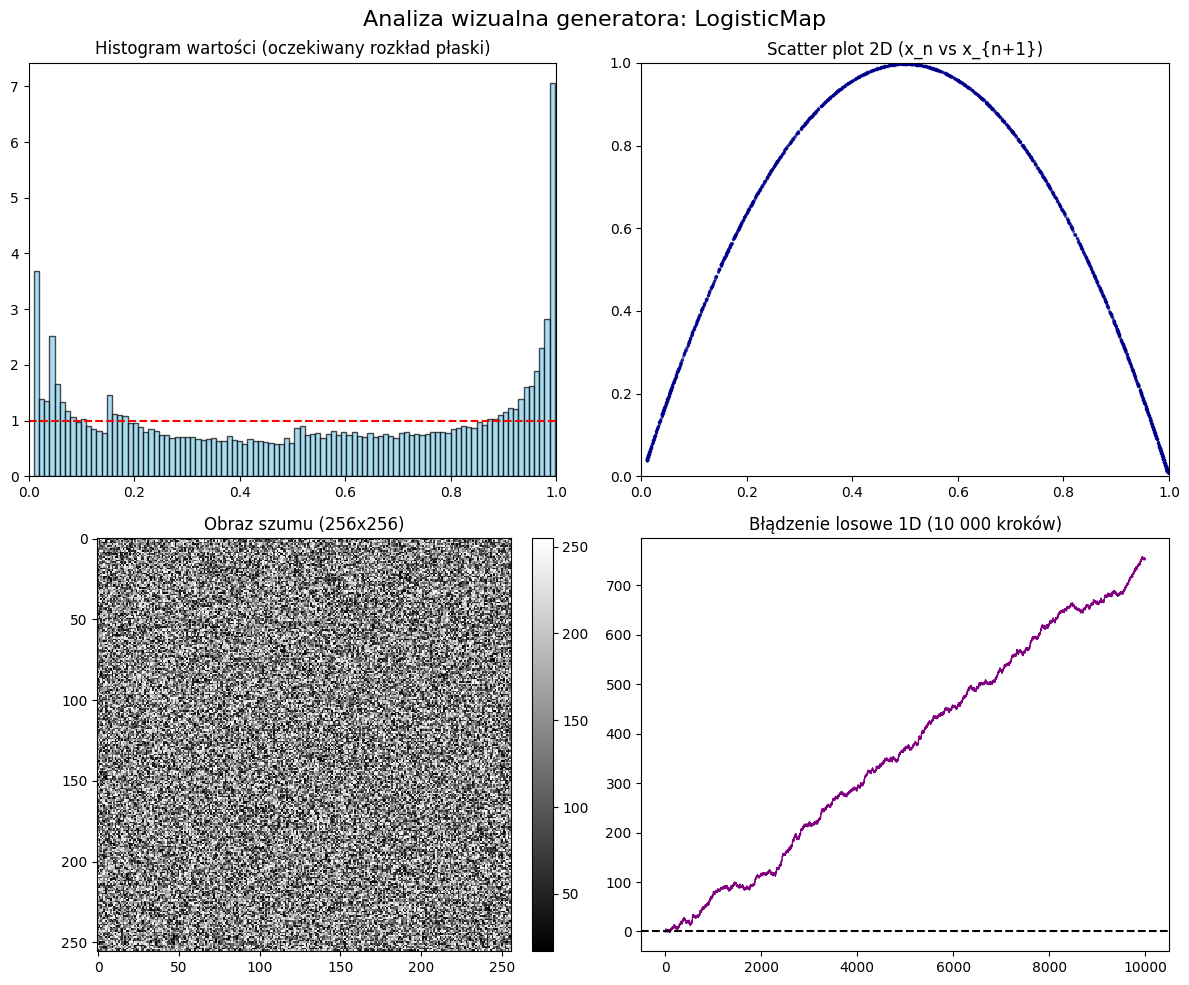

In [25]:
generator = LogisticMapGenerator()
run_visual_tests(generator)

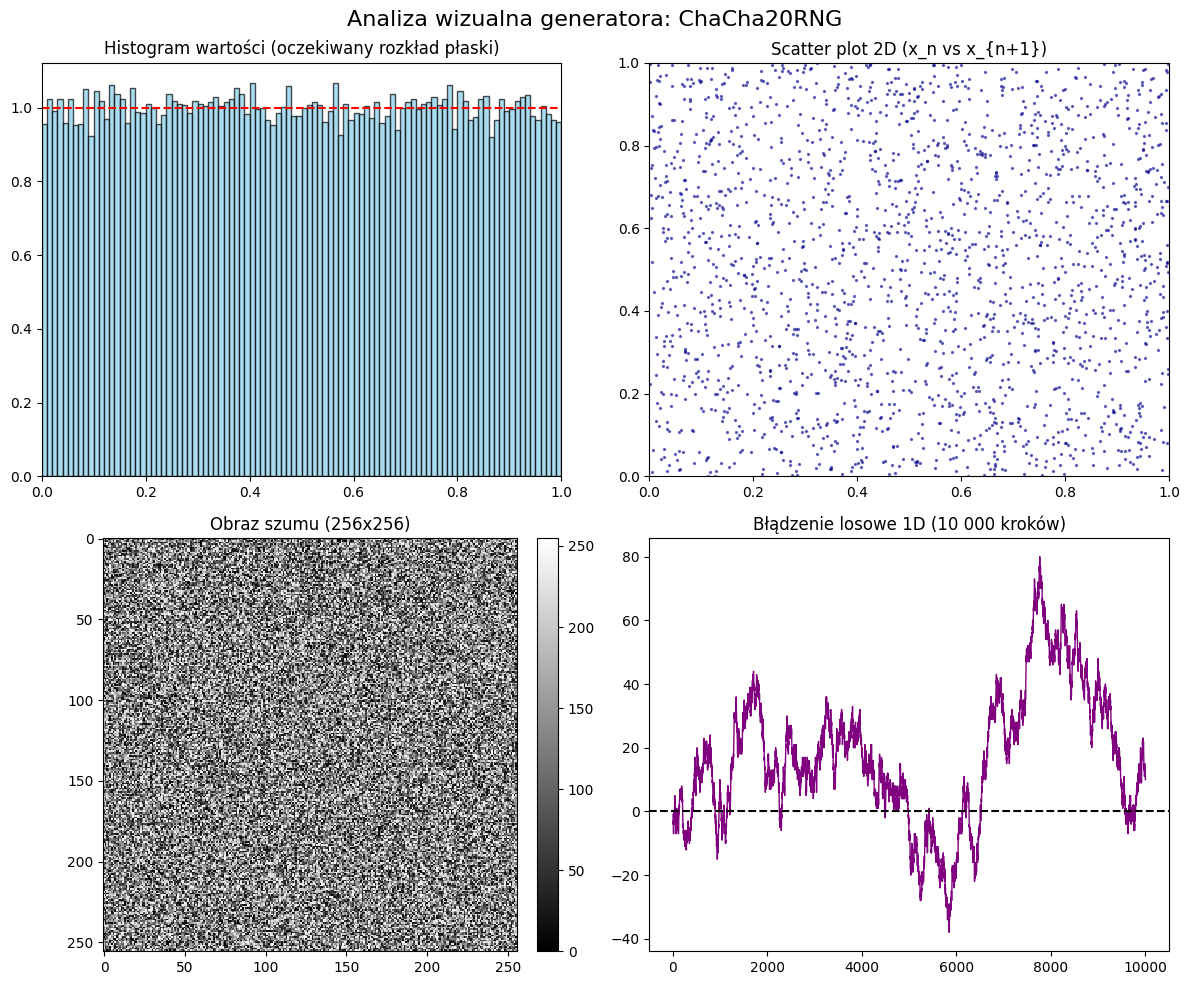

In [20]:
generator = ChaCha20RNG(seed=12345)
run_visual_tests(generator)

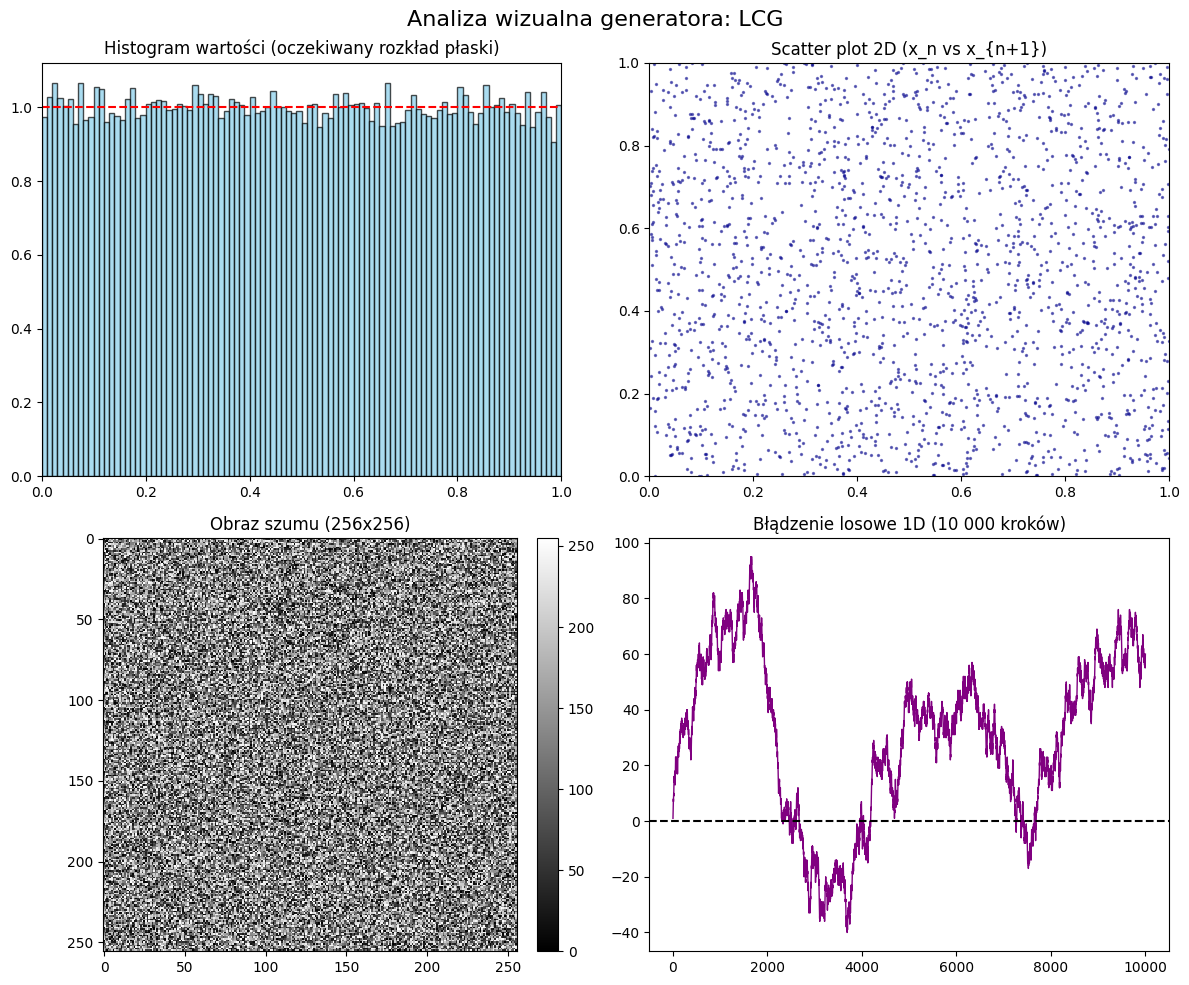

In [22]:
generator = LCGGenerator(seed=0)
run_visual_tests(generator)